# Neural Networks: From Architecture to Learning

*A single-layer perceptron cannot learn XOR — Minsky and Papert proved it, and the field spent a winter believing them; the fix was simply to add a layer and let the gradient flow backward through it.*

**Companion notebook to Chapter 55 — Neural Networks: From Architecture to Learning.**

The chapter builds its argument on three figures, and this notebook regenerates all of them. It is meant to be run and extended: change the activation set, the synthetic data, or the decision threshold, and watch the story change.

- `fig55_nb1_activations.png` — the sigmoid, tanh, and ReLU activations with their derivatives (Figure 55.2)
- `fig55_nb2_training_curve.png` — training vs. validation loss with early stopping (Figure 55.3)
- `fig55_nb3_crack_classification.png` — confusion matrix and the micro-crack cutoff trade-off (Figure 55.4)


In [1]:
# !pip install numpy matplotlib scikit-learn scipy
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
from scipy.interpolate import PchipInterpolator
%matplotlib inline

# Reproducibility: every source of randomness in this notebook is seeded so the
# figures regenerate identically on every run.
DATA_SEED  = 11   # synthetic-data generator (np.random.default_rng)
SPLIT_SEED = 0    # train/validation split
MODEL_SEED = 1    # MLP weight initialization and mini-batch shuffling

NL = chr(10)   # newline for multi-line plot labels (avoids escape issues)
OUT_DIR = pathlib.Path('../src/media/ch55'); OUT_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 12})
COPPER, STEEL, GREEN = '#c8631b', '#3b6ea5', '#2e8b57'   # consistent series colors


---
## 1 — Activation functions and their derivatives (Figure 55.2)


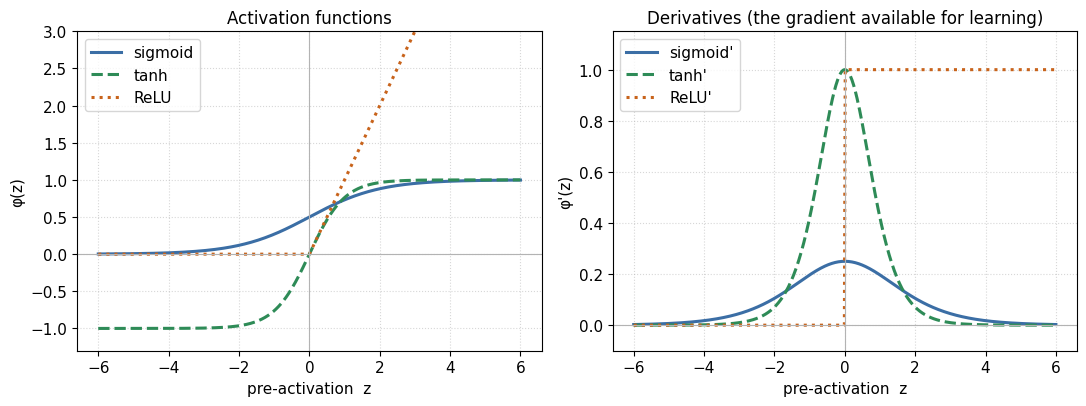

max sigmoid derivative = 0.24999096410944352


In [2]:
# The activation functions of Listing 55.1, plotted here alongside their derivatives.
# Each maps a pre-activation z to an activation; backpropagation multiplies by the
# derivative, so the shape of the derivative governs how well a gradient survives
# the trip back through the layers.

def sigmoid(z):
    """Logistic sigmoid, squashing z into the open interval (0, 1)."""
    return 1.0 / (1.0 + np.exp(-z))

def tanh(z):
    """Hyperbolic tangent: a zero-centered squashing into (-1, 1)."""
    return np.tanh(z)

def relu(z):
    """Rectified linear unit: pass positive z through, clamp negatives to 0."""
    return np.maximum(0.0, z)

def d_sigmoid(z):
    """Derivative of the sigmoid; peaks at 0.25 at z=0 and vanishes in both tails."""
    s = sigmoid(z)
    return s * (1.0 - s)

def d_tanh(z):
    """Derivative of tanh; peaks at 1.0 at z=0 and vanishes in both tails."""
    return 1.0 - np.tanh(z) ** 2

def d_relu(z):
    """Derivative of ReLU: 1 where the neuron is active, exactly 0 where it is dead."""
    return (z > 0).astype(float)

z = np.linspace(-6, 6, 500)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

ax1.plot(z, sigmoid(z), color=STEEL,  lw=2.2, ls='-',  label='sigmoid')
ax1.plot(z, tanh(z),    color=GREEN,  lw=2.2, ls='--', label='tanh')
ax1.plot(z, relu(z),    color=COPPER, lw=2.2, ls=':',  label='ReLU')
ax1.axhline(0, color='0.7', lw=0.8); ax1.axvline(0, color='0.7', lw=0.8)
ax1.set_title('Activation functions'); ax1.set_xlabel('pre-activation  z')
ax1.set_ylabel('φ(z)'); ax1.set_ylim(-1.3, 3.0)
ax1.legend(loc='upper left'); ax1.grid(True, linestyle=':', alpha=0.5)

ax2.plot(z, d_sigmoid(z), color=STEEL,  lw=2.2, ls='-',  label="sigmoid'")
ax2.plot(z, d_tanh(z),    color=GREEN,  lw=2.2, ls='--', label="tanh'")
ax2.plot(z, d_relu(z),    color=COPPER, lw=2.2, ls=':',  label="ReLU'")
ax2.axhline(0, color='0.7', lw=0.8); ax2.axvline(0, color='0.7', lw=0.8)
ax2.set_title('Derivatives (the gradient available for learning)')
ax2.set_xlabel('pre-activation  z'); ax2.set_ylabel("φ'(z)")
ax2.set_ylim(-0.1, 1.15)
ax2.legend(loc='upper left'); ax2.grid(True, linestyle=':', alpha=0.5)

fig.tight_layout()
fig.savefig(OUT_DIR / 'fig55_nb1_activations.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('max sigmoid derivative =', d_sigmoid(z).max())


---
## 2 — Training vs. validation loss with early stopping (Figure 55.3)

Reading the loss curves is the first thing to do after any training run — it is where overfitting, underfitting, and a mis-set learning rate all announce themselves before a single test-set number is computed. To make that visible we train a small synthetic three-class problem (**intact / micro-crack / developed**) epoch by epoch with `partial_fit`, recording the cross-entropy loss on both the training and validation splits after every pass.

The full crack-detection model of Listing 55.2 is a Keras network with dropout and batch normalization; scikit-learn's `MLPClassifier` has neither. It stands in here purely to illustrate the *training dynamics* of Figure 55.3: a little label noise and deliberately modest capacity let the mild overfitting — training loss still falling while validation loss has bottomed out and started to rise — emerge cleanly, which is exactly the signature early stopping is meant to catch.


validation minimum at epoch 53  val loss = 0.436


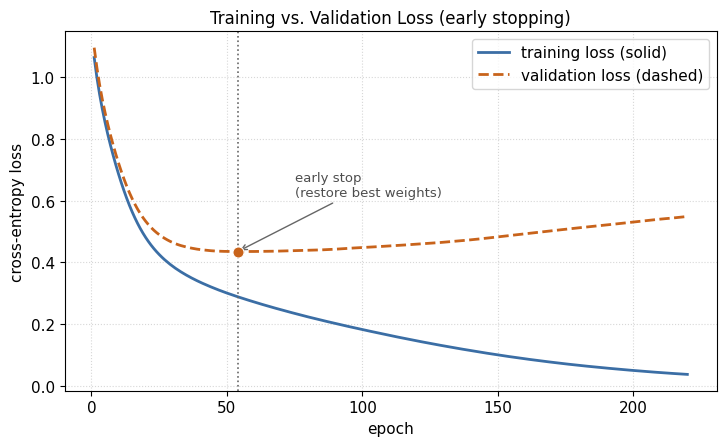

In [3]:
rng = np.random.default_rng(DATA_SEED)

N_FEATURES   = 24                # 6 features x 4 rosettes (Chapter 55 worked example)
N_PER_CLASS  = (500, 200, 150)   # intact / micro-crack / developed  -> 850 windows
CLASS_LEVELS = (0.0, 1.0, 2.2)   # how far each class shifts the cross-sensor pattern
LABEL_NOISE  = 0.08              # fraction of labels randomly corrupted (~8%)
VAL_FRACTION = 0.25              # held-out validation split
N_EPOCHS     = 220               # training epochs recorded for the loss curve


def make_windows(n, level):
    """Synthesize ``n`` rosette-derived feature vectors for one damage class.

    Returns an ``(n, N_FEATURES)`` array of standard-normal noise onto which a
    ``level``-scaled signature is stamped: the first four features carry an
    amplitude shift and the next four an angle rotation. Larger ``level`` values
    make a class progressively easier to separate from the intact (level 0)
    baseline, mimicking how a growing crack redistributes strain across sensors.
    """
    base = rng.normal(0, 1, size=(n, N_FEATURES))
    base[:, :4]  += 1.6 * level                              # amplitude shift
    base[:, 4:8] += 0.9 * level * rng.normal(1, 0.3, (n, 4)) # angle rotation
    return base


X = np.vstack([make_windows(n, lvl) for n, lvl in zip(N_PER_CLASS, CLASS_LEVELS)])
y = np.concatenate([np.full(n, k) for k, n in enumerate(N_PER_CLASS)])

flip = rng.random(len(y)) < LABEL_NOISE       # inject label noise
y[flip] = rng.integers(0, 3, flip.sum())

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=VAL_FRACTION,
                                            random_state=SPLIT_SEED, stratify=y)
sc = StandardScaler().fit(X_tr)
X_tr, X_val = sc.transform(X_tr), sc.transform(X_val)

# sklearn MLP as a stand-in for the Keras model of Listing 55.2 (no dropout /
# batch-norm); modest capacity plus label noise is what makes overfitting visible.
clf = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                    alpha=3e-5, learning_rate_init=6e-4, random_state=MODEL_SEED,
                    warm_start=True, max_iter=1)
classes = np.array([0, 1, 2])
tr_loss, val_loss = [], []
for epoch in range(N_EPOCHS):
    clf.partial_fit(X_tr, y_tr, classes=classes)
    tr_loss.append(log_loss(y_tr,  clf.predict_proba(X_tr),  labels=classes))
    val_loss.append(log_loss(y_val, clf.predict_proba(X_val), labels=classes))

best = int(np.argmin(val_loss))
print('validation minimum at epoch', best, ' val loss = %.3f' % val_loss[best])

fig, ax = plt.subplots(figsize=(7.4, 4.6))
ep = np.arange(1, len(tr_loss) + 1)
ax.plot(ep, tr_loss,  color=STEEL,  lw=2.0, ls='-',  label='training loss (solid)')
ax.plot(ep, val_loss, color=COPPER, lw=2.0, ls='--', label='validation loss (dashed)')
ax.axvline(best + 1, color='0.4', lw=1.2, ls=':')   # dotted: keeps it distinct from the dashed validation curve
ax.plot(best + 1, val_loss[best], 'o', color=COPPER, ms=8, mec='white', mew=0.8, zorder=5)
ax.annotate('early stop' + NL + '(restore best weights)', xy=(best + 1, val_loss[best]),
            xytext=(best + 22, val_loss[best] + 0.18), fontsize=9.5, color='0.3',
            arrowprops=dict(arrowstyle='->', color='0.4', lw=1.0))
ax.set_xlabel('epoch'); ax.set_ylabel('cross-entropy loss')
ax.set_title('Training vs. Validation Loss (early stopping)')
ax.legend(); ax.grid(True, linestyle=':', alpha=0.5)
fig.tight_layout()
fig.savefig(OUT_DIR / 'fig55_nb2_training_curve.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


---
## 3 — Confusion matrix + micro-crack cutoff trade-off (Figure 55.4)

Two evaluation views answer two different questions. The **confusion matrix** shows where the network is right and where it confuses one damage state for another — the diagonal is correct classifications, and the micro-crack row is where the errors concentrate because its strain signature is faint. The **cutoff trade-off** then shows that the operating point is an engineering decision, not a mathematical one: lowering the score cutoff for flagging a micro-crack buys micro-crack sensitivity at the price of more false alarms on intact joints.

The confusion counts and the two marked operating points (79% sensitivity at 6% false-positive for a 0.50 cutoff; 91% at 14% for 0.35) are illustrative values for the chapter's hypothetical welded-joint study, not the output of a trained model.


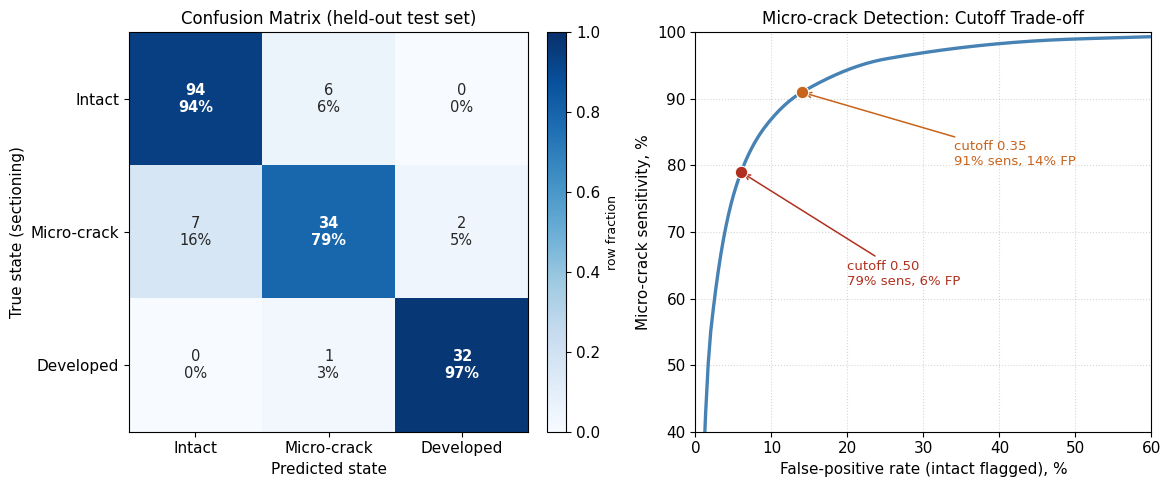

class accuracies: ['94%', '79%', '97%']


In [4]:
CLASS_NAMES = ['Intact', 'Micro-crack', 'Developed']

# Illustrative held-out confusion counts (rows = true state from post-test
# sectioning, cols = network prediction). Diagonals give 94% / 79% / 97%.
cm = np.array([[94, 6, 0],
               [7, 34, 2],
               [0, 1, 32]], dtype=float)
cm_frac = cm / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.0))

im = ax1.imshow(cm_frac, cmap='Blues', vmin=0, vmax=1)
ax1.set_xticks(range(3)); ax1.set_yticks(range(3))
ax1.set_xticklabels(CLASS_NAMES); ax1.set_yticklabels(CLASS_NAMES)
ax1.set_xlabel('Predicted state'); ax1.set_ylabel('True state (sectioning)')
ax1.set_title('Confusion Matrix (held-out test set)')
for i in range(3):
    for j in range(3):
        frac = cm_frac[i, j]
        label = str(int(cm[i, j])) + NL + ('%.0f%%' % (frac * 100))
        ax1.text(j, i, label, ha='center', va='center',
                 color='white' if frac > 0.5 else '0.15', fontsize=10.5,
                 fontweight='bold' if i == j else 'normal')
cbar = fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
cbar.set_label('row fraction', fontsize=9)

# Micro-crack ROC: monotone spline through illustrative anchor points, with the
# two operating points the text discusses marked on it.
fp_anchor = np.array([0.0, 0.02, 0.06, 0.10, 0.14, 0.25, 0.50, 1.0])
se_anchor = np.array([0.0, 0.55, 0.79, 0.87, 0.91, 0.96, 0.99, 1.0])
pchip = PchipInterpolator(fp_anchor, se_anchor)
fp = np.linspace(0, 1, 300)
ax2.plot(fp * 100, pchip(fp) * 100, color='steelblue', lw=2.4, zorder=3, label='micro-crack ROC')
for fpv, sev, col in [(0.06, 0.79, '#b0301f'), (0.14, 0.91, '#c8631b')]:
    ax2.plot(fpv * 100, sev * 100, 'o', color=col, ms=9, mec='white', mew=0.8, zorder=5)
ax2.annotate('cutoff 0.50' + NL + '79% sens, 6% FP', xy=(6, 79), xytext=(20, 62),
             fontsize=9.5, color='#b0301f', ha='left',
             arrowprops=dict(arrowstyle='->', color='#b0301f', lw=1.1))
ax2.annotate('cutoff 0.35' + NL + '91% sens, 14% FP', xy=(14, 91), xytext=(34, 80),
             fontsize=9.5, color='#c8631b', ha='left',
             arrowprops=dict(arrowstyle='->', color='#c8631b', lw=1.1))
ax2.set_xlabel('False-positive rate (intact flagged), %')
ax2.set_ylabel('Micro-crack sensitivity, %')
ax2.set_title('Micro-crack Detection: Cutoff Trade-off')
ax2.set_xlim(0, 60); ax2.set_ylim(40, 100)
ax2.grid(True, linestyle=':', alpha=0.5)

fig.tight_layout()
fig.savefig(OUT_DIR / 'fig55_nb3_crack_classification.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('class accuracies:', ['%.0f%%' % (cm_frac[i, i] * 100) for i in range(3)])


---
## Where to take this next

These figures are starting points, not finished results. Three concrete extensions, in rough order of effort:

1. **Add Leaky ReLU and watch the derivative panel change.** Define `leaky_relu(z, alpha=0.01)` (`np.where(z > 0, z, alpha * z)`) and its derivative (`np.where(z > 0, 1.0, alpha)`), then add both to Figure 55.2. The *dying ReLU* point the chapter makes turns visual: the derivative that sat at a flat zero for `z < 0` now holds a small positive `alpha` — precisely the surviving gradient that lets a dead neuron come back to life.

2. **Replace the sklearn stand-in with the real Keras model of Listing 55.2.** Build the actual three-class network — `Dense(48) → BatchNorm → ReLU → Dropout(0.25) → Dense(24) → BatchNorm → ReLU → Dropout(0.25) → Dense(3, softmax)` — train it on the same synthetic windows, and plot the returned `history` object. Then ablate: turn dropout and batch normalization off and watch how much earlier the validation curve in Figure 55.3 turns upward.

3. **Draw the ROC from real predictions, then calibrate it.** Figure 55.4's trade-off curve is drawn through illustrative anchor points. Instead, sweep the decision threshold across a trained model's actual softmax outputs (`np.linspace(0, 1, 200)`), compute sensitivity and false-positive rate at each, and plot the measured curve. Finally, apply temperature scaling or reliability-diagram binning — the calibration caution the chapter raises — and check how far the raw softmax scores sit from true probabilities.
